# 01d — Cd44 source, and the metabolic state of Spp1+ tumour vs Spp1+ macrophages

All in **single-cell** (`annotation_v4.h5ad`) — dissociated, so no segmentation spillover.
Three questions the spatial data cannot answer cleanly:

1. **Who produces Cd44** — the receptor side of the axis 01c showed is tumour-driven on the
   ligand side. Together they say *tumour Spp1 -> whose CD44?*
2. **Metabolic state of Spp1-high vs Spp1-low cancer cells** — is the tumour's Spp1 tied to a
   lipid/hypoxia program, or incidental?
3. **Do Spp1+ cancer cells and SPP1-TAM macrophages share a metabolic state?** — the real
   question. If the same program is induced in the Spp1-high fraction of *both* compartments,
   that is convergence onto a shared metabolic niche, which is the metabolism story's core.

### The one methodological trap, stated up front
The 01c `SPP1_TAM_sig` was **selected to be macrophage-specific** (>2x vs other types). Scoring
it on tumour cells is rigged to return ~0 and would "disprove" convergence by construction. So
convergence here is tested the honest way: **Spp1-high-vs-low DE run independently in each
compartment, then the fold-change vectors correlated.** Same genes moving the same way = a
shared program. Metabolic pathway scores are the interpretable companion, not the test.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

import scanpy as sc
import anndata as ad

from scipy.stats import mannwhitneyu, spearmanr

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 220)

## 1. Config + load (same reference as 01c)

In [2]:
SC_REF = Path("/coh_labs/yunroseli/Jona/CAR-T/data/zarr/fullDataset/"
              "annotating_references/annotation_v4.h5ad")
PATHWAY_DIR = Path("/coh_labs/yunroseli/Jona/CAR-T/data/references/pathways")
OUT_DIR = Path("/coh_labs/yunroseli/Jona/CAR-T/results/spp1_analysis")
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True); FIG_DIR.mkdir(parents=True, exist_ok=True)

GMT_FILES = {
    "hallmark": PATHWAY_DIR / "mh.all.v2026.1.Mm.symbols.gmt",
    "reactome": PATHWAY_DIR / "m2.cp.reactome.v2026.1.Mm.symbols.gmt",
    "go_bp":    PATHWAY_DIR / "m5.go.bp.v2026.1.Mm.symbols.gmt",
    "curated":  PATHWAY_DIR / "m2.cp.v2026.1.Mm.symbols.gmt",
}

TUMOUR_LABEL = "Cancer_cell"
MAC_LABELS   = ["M1_like_Mac", "M2_like_Mac", "Intermediate_Mac"]
HI_Q, LO_Q   = 0.75, 0.25
MIN_CELLS_DE = 100

assert SC_REF.exists(), f"reference not found: {SC_REF}"
scref = sc.read_h5ad(SC_REF)
print(scref)

# level auto-detect (same logic as 01c) — pick the lvl column with M1/M2/Cancer_cell
lvl_cols = [c for c in scref.obs.columns if c.startswith("cell_type_lvl")]
want = set(MAC_LABELS) | {TUMOUR_LABEL}
CT_COL = max(lvl_cols, key=lambda c: len(set(scref.obs[c].astype(str)) & want))
sc_ct = scref.obs[CT_COL].astype(str)
print(f"\nusing {CT_COL} | genes: {scref.n_vars:,}"
      + ("" if scref.n_vars > 20000 else "  <- gene-filtered; some metabolic genes may be absent"))
for lab in [TUMOUR_LABEL] + MAC_LABELS:
    print(f"  {lab}: {int((sc_ct == lab).sum()):,}")

# normalize a working copy if raw
X = scref.X
head = X[:200].toarray() if sp.issparse(X) else X[:200]
if bool(np.allclose(head, np.round(head))) and float(X.max()) > 50:
    scref.layers["counts"] = scref.X.copy()
    sc.pp.normalize_total(scref, target_sum=1e4); sc.pp.log1p(scref)
    print("\nnormalized raw counts -> CP10K + log1p")
else:
    print("\n.X already log-normalized")

def expr_of(a, gene):
    v = a[:, gene].X
    return np.asarray(v.todense()).ravel() if sp.issparse(v) else np.asarray(v).ravel()

AnnData object with n_obs × n_vars = 93548 × 22949
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Barcode', 'Library', 'condition', 'file_name', 'percent.mt', 'unintegrated_clusters', 'seurat_clusters', 'harmony_clusters', 'sctype_classification', 'seurat.cluster.ann', 'treatment', 'cell_type', 'UMAP_R_1', 'UMAP_R_2', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_res_0.1', 'leiden_res_0.3', 'leiden_res_0.5', 'leiden_res_1.0', 'cell_type_lvl1', 'leiden_res_0.4', 'cell_type_lvl1_ad', 'cell_type_lvl2', 'cell_type_lvl3'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'chromosome', 'start', 'end'
    uns: 'cell_type_lvl1_colo

## 2. Q1 — who produces Cd44?

Same per-cell + projected-to-tissue logic as 01c's Spp1 gate. Cd44 is a receptor and is
*legitimately* broad (activated lymphoid cells express it), so unlike Spp1 the point is not
"who is specific" but **which cell types form the dominant CD44 pool the tumour Spp1 could
signal to**. The ambient floor (~0.4 in 01c) still applies — read against it.

In [3]:
SPATIAL_N = {
    "Cancer_cell": 363019, "Erythrocyte": 210019, "N2_like_Neu": 193240, "N1_like_Neu": 134656,
    "M2_like_Mac": 60720, "Classical_Mono": 58279, "CD8_T": 45824, "B": 40422,
    "Fibroblast": 24867, "NK": 22924, "M1_like_Mac": 19170, "Endothelial": 17702,
    "CD4_T": 10085, "cDC": 8471, "NKT": 7110, "Treg": 5155, "pDC": 4558,
    "Nonclassical_Mono": 4002, "Intermediate_Mac": 1675,
}
assert "Cd44" in scref.var_names, "Cd44 not in var_names"
scref.obs["Cd44_expr"] = expr_of(scref, "Cd44")
scref.obs["Spp1_expr"] = expr_of(scref, "Spp1")

cd44 = (pd.DataFrame({"ct": sc_ct.values, "Cd44": scref.obs["Cd44_expr"].values})
        .groupby("ct")
        .agg(n_sc=("Cd44", "size"), mean_Cd44=("Cd44", "mean"),
             pct_detected=("Cd44", lambda s: 100 * (s > 0).mean())))
cd44["n_spatial"] = cd44.index.map(SPATIAL_N)
cd44["proj_Cd44"] = cd44["mean_Cd44"] * cd44["n_spatial"]
cd44["pct_of_tissue_Cd44"] = 100 * cd44["proj_Cd44"] / cd44["proj_Cd44"].sum()
cd44["reliable"] = cd44["n_sc"] >= 200
cd44 = cd44.sort_values("pct_of_tissue_Cd44", ascending=False)
cd44.to_csv(OUT_DIR / "sc_cd44_by_celltype.csv")

print("=== who carries Cd44 (per-cell x real spatial abundance) ===")
print(cd44.round(3).to_string())

tum_cd44 = cd44.loc[TUMOUR_LABEL, "pct_of_tissue_Cd44"] if TUMOUR_LABEL in cd44.index else np.nan
mac_cd44 = cd44.loc[[m for m in MAC_LABELS if m in cd44.index], "pct_of_tissue_Cd44"].sum()
print(f"""
tissue Cd44 pool: Cancer_cell {tum_cd44:.1f}%  |  macrophages {mac_cd44:.1f}%
  tumour high on BOTH Spp1 and Cd44 -> autocrine/juxtacrine tumour Spp1-CD44 loop; the deck's
      "interaction-high clusters" are largely tumour talking to itself.
  Cd44 spread across immune/stroma -> tumour Spp1 signals OUTWARD to a CD44+ compartment; then
      WHICH compartment (macs? T cells?) is the biology worth chasing.
""")

=== who carries Cd44 (per-cell x real spatial abundance) ===
                    n_sc  mean_Cd44  pct_detected  n_spatial   proj_Cd44  pct_of_tissue_Cd44  reliable
ct                                                                                                    
N2_like_Neu         1857      2.245        83.953     193240  433742.599              31.402      True
N1_like_Neu         1956      2.340        88.548     134656  315147.808              22.816      True
Cancer_cell         6614      0.515        34.351     363019  187017.313              13.540      True
Classical_Mono     25955      2.057        95.130      58279  119873.521               8.679      True
M2_like_Mac        23538      1.708        93.483      60720  103698.320               7.508      True
M1_like_Mac        15716      1.883        95.202      19170   36099.057               2.613      True
CD8_T                513      0.712        64.522      45824   32629.016               2.362      True
Erythrocyte 

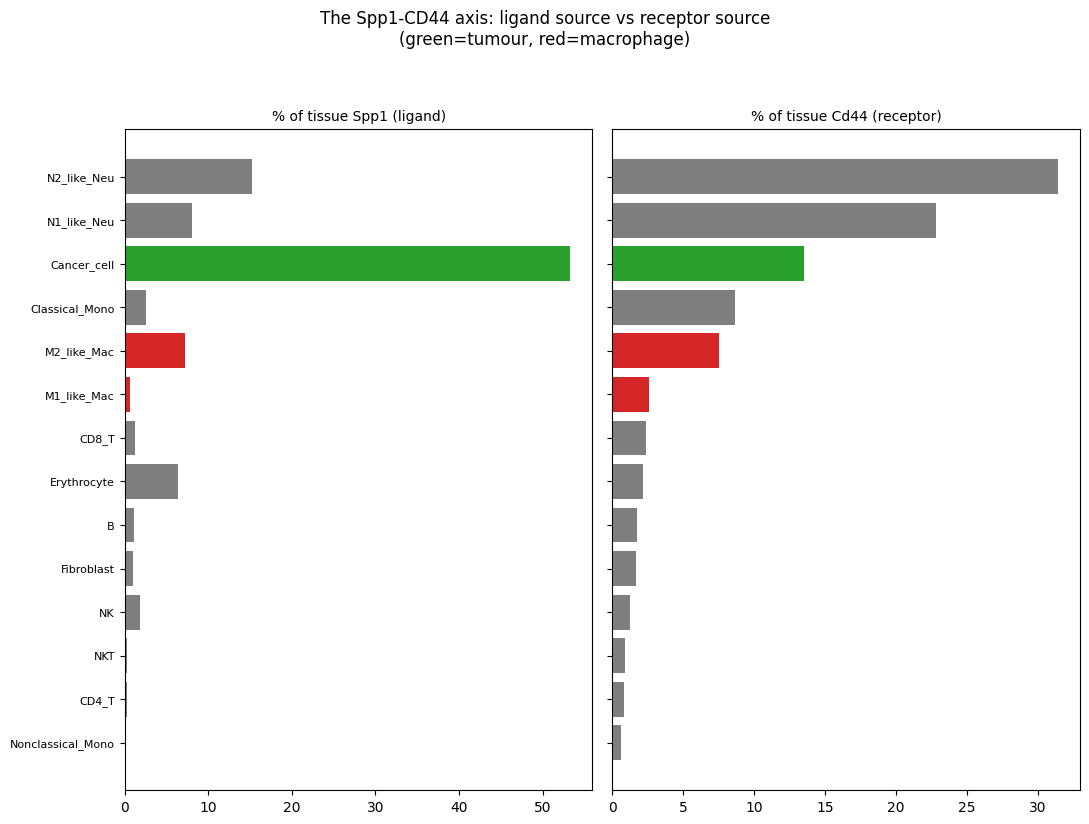

In [4]:
# Figure: Spp1 source (from 01c) vs Cd44 source, side by side.
spp1 = (pd.DataFrame({"ct": sc_ct.values, "Spp1": scref.obs["Spp1_expr"].values})
        .groupby("ct")["Spp1"].mean() * pd.Series(SPATIAL_N))
spp1 = 100 * spp1 / spp1.sum()
order = cd44.sort_values("pct_of_tissue_Cd44", ascending=False).index[:14]
y = np.arange(len(order))
colr = ["#2ca02c" if i == TUMOUR_LABEL else ("#d62728" if i in MAC_LABELS else "#7f7f7f") for i in order]
fig, axes = plt.subplots(1, 2, figsize=(11, 0.42 * len(order) + 2), sharey=True)
axes[0].barh(y, spp1.reindex(order).values, color=colr); axes[0].set_title("% of tissue Spp1 (ligand)", fontsize=10)
axes[1].barh(y, cd44.reindex(order)["pct_of_tissue_Cd44"].values, color=colr); axes[1].set_title("% of tissue Cd44 (receptor)", fontsize=10)
axes[0].set_yticks(y); axes[0].set_yticklabels(order, fontsize=8); axes[0].invert_yaxis()
fig.suptitle("The Spp1-CD44 axis: ligand source vs receptor source\n(green=tumour, red=macrophage)", y=1.04)
fig.tight_layout(); fig.savefig(FIG_DIR / "sc_spp1_cd44_sources.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 3. Metabolic pathway panel (scored on all cells)

The metabolism-angle pathways, verified present in the GMTs in earlier passes. Scored once on
the whole object; §4 and §5 read them back per compartment.

In [5]:
METAB_PANEL = {
    "Hypoxia_Hallmark": "HALLMARK_HYPOXIA",
    "Glycolysis_Hallmark": "HALLMARK_GLYCOLYSIS",
    "OxPhos_Hallmark": "HALLMARK_OXIDATIVE_PHOSPHORYLATION",
    "FattyAcid_Metab_Hallmark": "HALLMARK_FATTY_ACID_METABOLISM",
    "Cholesterol_Homeo_Hallmark": "HALLMARK_CHOLESTEROL_HOMEOSTASIS",
    "Adipogenesis_Hallmark": "HALLMARK_ADIPOGENESIS",
    "mTORC1_Hallmark": "HALLMARK_MTORC1_SIGNALING",
    "FAO_GO": "GOBP_FATTY_ACID_BETA_OXIDATION",
    "LipidDroplet_GO": "GOBP_LIPID_DROPLET_ORGANIZATION",
    "oxLDL_Response_GO": "GOBP_CELLULAR_RESPONSE_TO_OXIDISED_LOW_DENSITY_LIPOPROTEIN_PARTICLE_STIMULUS",
    "Cholesterol_Efflux_GO": "GOBP_CHOLESTEROL_EFFLUX",
    "Lactate_Metab_GO": "GOBP_LACTATE_METABOLIC_PROCESS",
    "Adenosine_Metab_GO": "GOBP_ADENOSINE_METABOLIC_PROCESS",
    "Glutamine_Metab_GO": "GOBP_GLUTAMINE_METABOLIC_PROCESS",
}

def read_gmt(p):
    out = {}
    for line in open(p):
        x = line.rstrip("\n").split("\t")
        if len(x) >= 3: out[x[0]] = x[2:]
    return out

gene_sets = {}
for _, p in GMT_FILES.items():
    gene_sets.update(read_gmt(p))

available = set(scref.var_names.astype(str))
metab_cols = []
for short, gs in METAB_PANEL.items():
    matched = [g for g in gene_sets.get(gs, []) if g in available]
    if len(matched) < 5:
        print(f"[skip] {short}: {len(matched)} genes"); continue
    sc.tl.score_genes(scref, gene_list=matched, score_name=short, use_raw=False, random_state=0)
    metab_cols.append(short)
print(f"{len(metab_cols)}/{len(METAB_PANEL)} metabolic pathways scored")

14/14 metabolic pathways scored


## 4. Q2 + Q3 setup — split each compartment by Spp1 (**arm-aware**)

### Why this changed (same fix as 01c §4)
05 showed Spp1 per cell is **4-25x higher in NoTx than in any treated arm**, in every compartment.
A tercile split pooled across all 29 samples therefore makes `Spp1_high` largely mean *"came from
an untreated mouse"* — in **both** the tumour and the macrophage compartment. That would make the
convergence test in §6 partly a test of whether tumour and macrophages *both respond to treatment*
(they do, trivially) rather than whether they share an **Spp1-driven** program.

The cell quantifies the confound per compartment, then splits **within sample**, so `Spp1_high`
means high relative to its own tissue. Every arm then contributes equally to both sides and the
treatment axis cancels.

**Re-run §5 (tumour DE), §5b/§5c (enrichment) and §6 (convergence) after this** — all three derive
from the split. The convergence r = +0.454 was computed on the pooled split.

In [ ]:
# %% -- 4. Split each compartment by Spp1 (ARM-AWARE; see 05 and 01c §4 for the confound) --
SPP1_SPLIT_SCOPE    = "within_sample"   # "within_sample" | "within_condition" | "global"
MIN_CELLS_FOR_SPLIT = 30                # blocks smaller than this stay 'mid'

# design columns from file_name: <condition>_Tu<loc>_<rep>  (e.g. RTCyPSCA_Tu1_2)
assert "file_name" in scref.obs.columns, "file_name not in obs — needed for the arm-aware split"
_p = scref.obs["file_name"].astype(str).str.extract(r"^(?P<cond>.*)_Tu(?P<tumor_loc>\d+)_(?P<rep>\d+)$")
assert _p["cond"].notna().all(), "some file_name values do not match <cond>_Tu<loc>_<rep>"
scref.obs["cond"]      = _p["cond"].values
scref.obs["tumor_loc"] = _p["tumor_loc"].astype(int).values
scref.obs["sample"]    = scref.obs["file_name"].astype(str).values

scref.obs["compartment"] = "other"
scref.obs.loc[sc_ct == TUMOUR_LABEL, "compartment"] = "tumour"
scref.obs.loc[sc_ct.isin(MAC_LABELS), "compartment"] = "mac"
comp_masks = {"tumour": (sc_ct == TUMOUR_LABEL).values, "mac": sc_ct.isin(MAC_LABELS).values}

def spp1_split(mask, scope):
    """Spp1 tercile split computed WITHIN `scope`, so between-sample/arm shifts cancel."""
    obs = scref.obs.loc[mask]
    grp = pd.Series("mid", index=obs.index, dtype=object)
    keys = {"global": None, "within_condition": ["cond", "tumor_loc"], "within_sample": ["sample"]}[scope]
    blocks = [(None, obs.index)] if keys is None else list(obs.groupby(keys, observed=True).groups.items())
    for _, idx in blocks:
        e = obs.loc[idx, "Spp1_expr"]
        if len(e) < MIN_CELLS_FOR_SPLIT:
            continue
        hi, lo = e.quantile(HI_Q), e.quantile(LO_Q)
        if not np.isfinite(hi) or not np.isfinite(lo) or hi <= lo:
            continue                        # degenerate (e.g. mostly zeros) -> leave as 'mid'
        grp.loc[e[e >= hi].index] = "Spp1_high"
        grp.loc[e[e <= lo].index] = "Spp1_low"
    return grp

def arm_enrichment(mask, grp):
    """log2 over-representation of each arm in the Spp1_high tercile of this compartment."""
    arms = scref.obs.loc[mask, "cond"]
    share = arms.value_counts(normalize=True).mul(100)
    hi = (arms[np.asarray(grp) == "Spp1_high"].value_counts(normalize=True).mul(100)
          .reindex(share.index).fillna(0.0))
    return share, hi, np.log2((hi / share).replace(0, np.nan))

print("=== CONFOUND CHECK: arm composition of the GLOBAL Spp1_high tercile, per compartment ===")
worst = {}
for comp, mask in comp_masks.items():
    share, hi, enr = arm_enrichment(mask, spp1_split(mask, "global").values)
    worst[comp] = float(enr.abs().max())
    print(f"\n  [{comp}]  n = {int(mask.sum()):,}")
    print("    % of Spp1_high from arm : " + "  ".join(f"{a}={hi[a]:.1f}" for a in share.index))
    print("    arm share of compartment: " + "  ".join(f"{a}={share[a]:.1f}" for a in share.index))
    print("    log2 enrichment         : " + "  ".join(f"{a}={enr[a]:+.2f}" for a in share.index))
    print(f"    |log2| max = {worst[comp]:.2f}   (~0 = unconfounded; NoTx >> 0 = 'high' means 'untreated')")

scref.obs["spp1_grp"] = "NA"
for comp, mask in comp_masks.items():
    scref.obs.loc[mask, "spp1_grp"] = spp1_split(mask, SPP1_SPLIT_SCOPE).values

scref.obs["comp_grp"] = scref.obs["compartment"] + "_" + scref.obs["spp1_grp"]
print(f"\n=== split used: SPP1_SPLIT_SCOPE = '{SPP1_SPLIT_SCOPE}' ===")
print(scref.obs.loc[scref.obs["compartment"] != "other", "comp_grp"].value_counts().to_string())
for comp, mask in comp_masks.items():
    _, _, enr = arm_enrichment(mask, scref.obs.loc[mask, "spp1_grp"].values)
    print(f"  [{comp}] |log2| max after the fix = {float(enr.abs().max()):.2f}   (was {worst[comp]:.2f})")

# Metabolic scores across the four groups.
grp_means = (scref.obs[scref.obs["comp_grp"].str.contains("Spp1")]
             .groupby("comp_grp")[metab_cols].mean().T)
grp_means = grp_means[[c for c in ["tumour_Spp1_high", "tumour_Spp1_low",
                                   "mac_Spp1_high", "mac_Spp1_low"] if c in grp_means.columns]]
grp_means.to_csv(OUT_DIR / "sc_metabolic_scores_by_group.csv")

print("\n=== metabolic pathway scores: mean per group ===")
print(grp_means.round(3).to_string())

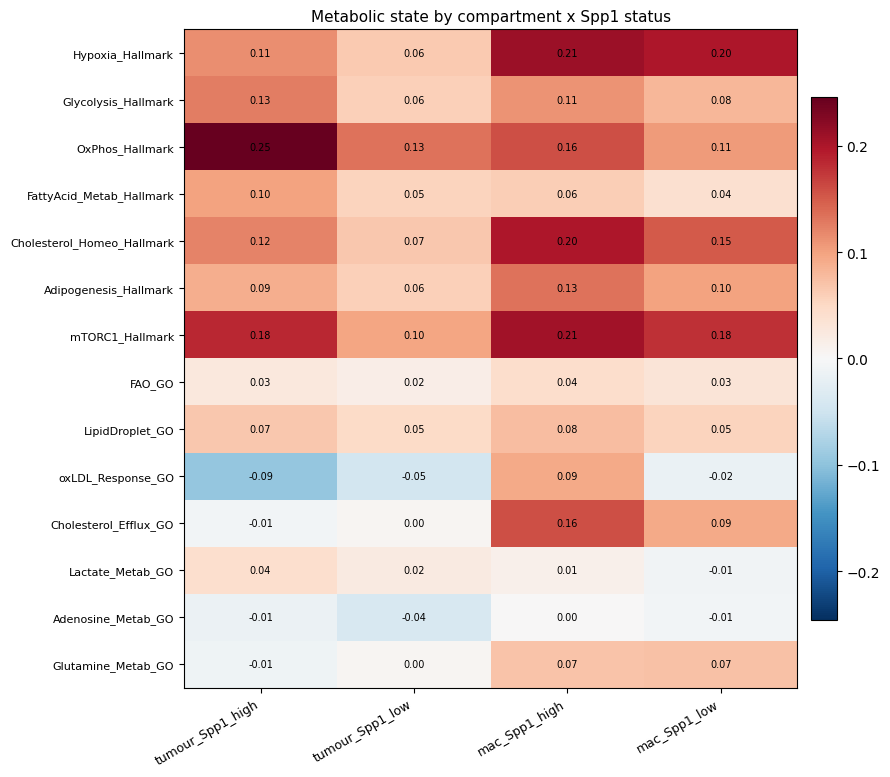

In [7]:
# Heatmap of the 2x2. The comparison that answers Q2 is tumour_high vs tumour_low; Q3 is
# whether the tumour_high and mac_high COLUMNS look alike.
data = grp_means.values.astype(float)
vmax = np.nanmax(np.abs(data)) or 1.0
fig, ax = plt.subplots(figsize=(1.5 * data.shape[1] + 3, 0.42 * data.shape[0] + 2))
im = ax.imshow(data, cmap="RdBu_r", norm=TwoSlopeNorm(0, -vmax, vmax), aspect="auto")
ax.set_xticks(range(data.shape[1])); ax.set_xticklabels(grp_means.columns, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(data.shape[0])); ax.set_yticklabels(grp_means.index, fontsize=8)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, f"{data[i,j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("Metabolic state by compartment x Spp1 status", fontsize=11)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
fig.tight_layout(); fig.savefig(FIG_DIR / "sc_metabolic_2x2.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 5. Q2 — DE: Spp1-high vs Spp1-low cancer cells

Is the tumour's Spp1 tied to a metabolic program, or incidental?

In [8]:
def de_high_vs_low(mask, tag, tie_correct=False):
    sub = scref[mask & scref.obs["spp1_grp"].isin(["Spp1_high", "Spp1_low"]).values].copy()
    n_hi = int((sub.obs["spp1_grp"] == "Spp1_high").sum())
    n_lo = int((sub.obs["spp1_grp"] == "Spp1_low").sum())
    if n_hi < MIN_CELLS_DE or n_lo < MIN_CELLS_DE:
        print(f"[{tag}] too few cells (hi={n_hi}, lo={n_lo})"); return None
    sc.pp.filter_genes(sub, min_cells=10)
    sc.tl.rank_genes_groups(sub, "spp1_grp", groups=["Spp1_high"], reference="Spp1_low",
                            method="wilcoxon", pts=True, tie_correct=tie_correct)
    r = sub.uns["rank_genes_groups"]
    df = pd.DataFrame({"gene": [x[0] for x in r["names"]],
                       "log2FC": [x[0] for x in r["logfoldchanges"]],
                       "score": [x[0] for x in r["scores"]],
                       "pval_adj": [x[0] for x in r["pvals_adj"]]})
    # keep detection rates (pts=True already computes them) -> sparsity diagnostic in 5d
    df["pct_high"] = df["gene"].map(r["pts"]["Spp1_high"])
    df["pct_low"] = df["gene"].map(r["pts"]["Spp1_low"])
    print(f"[{tag}] DE done: {n_hi} high vs {n_lo} low  (tie_correct={tie_correct})")
    return df

de_tum = de_high_vs_low((sc_ct == TUMOUR_LABEL).values, "tumour")
de_mac = de_high_vs_low(sc_ct.isin(MAC_LABELS).values, "mac")
de_tum.to_csv(OUT_DIR / "sc_de_spp1_tumour.csv", index=False)
de_mac.to_csv(OUT_DIR / "sc_de_spp1_mac.csv", index=False)
assert de_tum is not None and de_mac is not None, \
    "DE skipped: a compartment had <MIN_CELLS_DE Spp1-high/low cells; convergence (cell below) needs both."

print("\n=== Spp1-high vs Spp1-low CANCER cells — top 25 UP ===")
print(de_tum.nlargest(25, "score")[["gene", "log2FC", "pval_adj"]].round(3).to_string(index=False))

# Do the metabolic programs move in Spp1-high tumour?
CHECK = {"lipid/TAM": ["Trem2","Apoe","Fabp5","Cd63","Lgals3","Lpl","Plin2","Cd36"],
         "cholesterol": ["Hmgcr","Ldlr","Scd1","Srebf2","Fdps"],
         "hypoxia/glyco": ["Hif1a","Vegfa","Ldha","Slc2a1","Pgk1"]}
idx = de_tum.set_index("gene")
print("\n--- metabolic markers in Spp1-high tumour ---")
for name, genes in CHECK.items():
    pres = [g for g in genes if g in idx.index]
    if pres:
        s = idx.loc[pres, ["log2FC", "pval_adj"]].sort_values("log2FC", ascending=False)
        print(f"\n  {name}: " + ", ".join(f"{g}({s.loc[g,'log2FC']:+.2f})" for g in s.index))

[tumour] DE done: 1654 high vs 1657 low
[mac] DE done: 12119 high vs 15001 low

=== Spp1-high vs Spp1-low CANCER cells — top 25 UP ===
    gene    log2FC  pval_adj
    Spp1 35.969002       0.0
    Ctsl  4.223000       0.0
    Cd63  3.419000       0.0
     Cd9  3.699000       0.0
     Clu  4.448000       0.0
  Tm4sf1  3.861000       0.0
Serpinh1  3.419000       0.0
Serpinf1  3.872000       0.0
    Ibsp  4.844000       0.0
Serpine2  3.882000       0.0
    Calu  3.490000       0.0
    Ctsb  2.393000       0.0
   Timp2  3.080000       0.0
     Ank  2.922000       0.0
   Pdia3  2.902000       0.0
   Timp1  3.475000       0.0
    Ppic  3.924000       0.0
   Pdia6  3.266000       0.0
   Ptges  2.999000       0.0
     Bsg  2.529000       0.0
    Areg  3.972000       0.0
  Igfbp4  2.407000       0.0
  S100a6  1.745000       0.0
   Mfge8  3.837000       0.0
    Ssr3  2.319000       0.0

--- metabolic markers in Spp1-high tumour ---

  lipid/TAM: Cd63(+3.42), Fabp5(+0.69), Plin2(+0.61), Lgals3(-0

## 5b-5c. Enrichment of the Spp1-high tumour DE, and pathway-level convergence

Section 5 eyeballs a handful of metabolic genes. This runs the **same enrichment engine as 01c
§4c** (rank-based Mann-Whitney U -> signed z + AUC, plus a hypergeometric ORA on the up-genes)
on the *cancer-cell* DE, so "the tumour's Spp1 is tied to a metabolic program" becomes a
quantitative statement: do metabolic gene **sets** concentrate at the Spp1-high end, above the
non-metabolic Hallmark backdrop?

§5c then runs it on the macrophage DE too and plots tumour vs macrophage enrichment z per set —
the pathway-level companion to §6's gene-level convergence r. Programs in the upper-right are
induced with Spp1 in **both** compartments (the shared niche); off-diagonal programs are the
compartment's own labour (macs scavenge/efflux lipid, tumour synthesises it).

[tumour] background 12,991 genes | up-genes (padj<0.05 & log2FC>1): 2,189
[mac] background 17,397 genes | up-genes (padj<0.05 & log2FC>1): 640

=== TOP enriched up in Spp1-high TUMOUR (all sets; metabolic flagged) ===
                            pathway  n_genes   AUC      z  fdr_rank  n_up_overlap  metabolic
                   H:MYC_TARGETS_V1      185 0.899 18.660       0.0            91      False
        H:OXIDATIVE_PHOSPHORYLATION      180 0.796 13.641       0.0            67       True
                 H:MTORC1_SIGNALING      188 0.724 10.581       0.0            64       True
                      H:E2F_TARGETS      192 0.699  9.487       0.0            54      False
        H:UNFOLDED_PROTEIN_RESPONSE      102 0.751  8.743       0.0            44      False
                   H:G2M_CHECKPOINT      181 0.681  8.376       0.0            39      False
                       H:DNA_REPAIR      137 0.689  7.604       0.0            38      False
                H:PROTEIN_SECRETION   

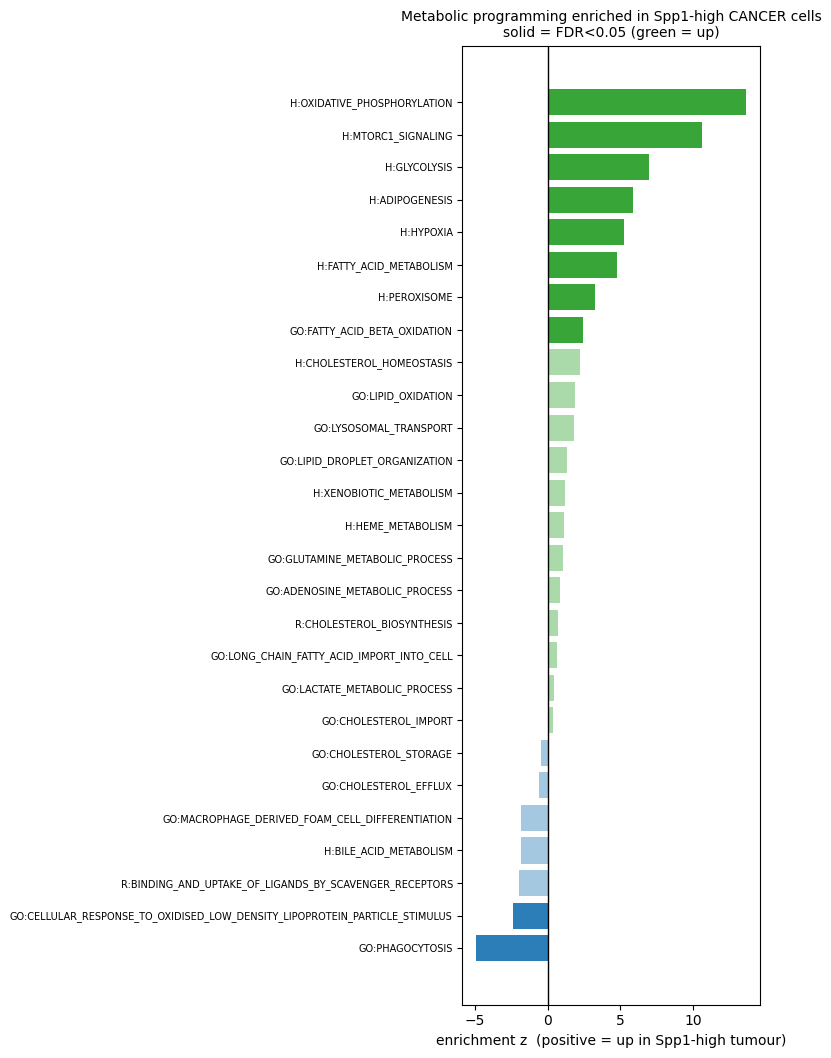


saved -> /coh_labs/yunroseli/Jona/CAR-T/results/spp1_analysis/figures/sc_tumour_metabolic_enrichment.png


In [12]:
# %% -- 5b. Metabolic + Hallmark enrichment of the Spp1-high vs -low TUMOUR DE (engine = 01c 4c) --
from scipy.stats import norm, hypergeom
from statsmodels.stats.multitest import multipletests
import matplotlib.colors as mcolors

METAB_FOCUS = [
    "GOBP_FATTY_ACID_BETA_OXIDATION", "GOBP_LIPID_DROPLET_ORGANIZATION",
    "GOBP_CELLULAR_RESPONSE_TO_OXIDISED_LOW_DENSITY_LIPOPROTEIN_PARTICLE_STIMULUS",
    "GOBP_LIPID_OXIDATION", "GOBP_CHOLESTEROL_EFFLUX", "GOBP_CHOLESTEROL_STORAGE",
    "GOBP_CHOLESTEROL_IMPORT", "REACTOME_CHOLESTEROL_BIOSYNTHESIS",
    "GOBP_LONG_CHAIN_FATTY_ACID_IMPORT_INTO_CELL", "GOBP_LACTATE_METABOLIC_PROCESS",
    "GOBP_ADENOSINE_METABOLIC_PROCESS", "GOBP_GLUTAMINE_METABOLIC_PROCESS",
    "GOBP_MACROPHAGE_DERIVED_FOAM_CELL_DIFFERENTIATION",
    "REACTOME_BINDING_AND_UPTAKE_OF_LIGANDS_BY_SCAVENGER_RECEPTORS",
    "GOBP_PHAGOCYTOSIS", "GOBP_LYSOSOMAL_TRANSPORT",
]
hallmark = {k: v for k, v in gene_sets.items() if k.startswith("HALLMARK_")}
panel = dict(hallmark)
for gs in METAB_FOCUS:
    if gs in gene_sets:
        panel[gs] = gene_sets[gs]
    else:
        print("missing from GMT:", gs)
METAB_HALLMARK_KEYS = ["GLYCOLYSIS", "OXIDATIVE_PHOS", "FATTY_ACID", "CHOLESTEROL", "ADIPO",
                       "MTORC1", "HYPOXIA", "BILE_ACID", "HEME", "PEROXISOME", "XENOBIOTIC"]
metab_tag = set(METAB_FOCUS) | {h for h in hallmark if any(k in h for k in METAB_HALLMARK_KEYS)}

def enrich_de(de, tag):
    """Signed rank enrichment (MWU U -> z, AUC) + hypergeometric ORA of a Spp1-high-vs-low DE."""
    ds = de.set_index("gene")["score"].dropna()
    ranked = ds.sort_values(); N = len(ranked)
    rankpos = pd.Series(np.arange(1, N + 1), index=ranked.index)     # high rank = up in Spp1-high
    tested = set(ranked.index)
    up_genes = set(de[(de["pval_adj"] < 0.05) & (de["log2FC"] > 1)]["gene"]) & tested
    K = len(up_genes)
    rows = []
    for name, members in panel.items():
        m = [g for g in set(members) if g in tested]; n = len(m)
        if n < 5:
            continue
        U = rankpos.loc[m].sum() - n * (n + 1) / 2                   # MWU U, in-set vs rest
        mu = n * (N - n) / 2; sd = np.sqrt(n * (N - n) * (N + 1) / 12)
        z = (U - mu) / sd; auc = U / (n * (N - n))                   # AUC > 0.5 = up in Spp1-high
        k = len(set(m) & up_genes)
        p_ora = float(hypergeom.sf(k - 1, N, K, n)) if K else np.nan
        rows.append({"pathway": name.replace("HALLMARK_", "H:").replace("GOBP_", "GO:").replace("REACTOME_", "R:"),
                     "raw": name, "n_genes": n, "AUC": round(auc, 3), "z": z,
                     "p_rank": float(2 * norm.sf(abs(z))), "n_up_overlap": k,
                     "p_ora": p_ora, "metabolic": name in metab_tag})
    enr = pd.DataFrame(rows)
    enr["fdr_rank"] = multipletests(enr["p_rank"], method="fdr_bh")[1]
    enr["fdr_ora"] = np.nan
    ok = enr["p_ora"].notna()
    if ok.any():
        enr.loc[ok, "fdr_ora"] = multipletests(enr.loc[ok, "p_ora"], method="fdr_bh")[1]
    enr = enr.sort_values("z", ascending=False)
    enr.to_csv(OUT_DIR / f"sc_de_{tag}_metabolic_enrichment.csv", index=False)
    print(f"[{tag}] background {N:,} genes | up-genes (padj<0.05 & log2FC>1): {K:,}")
    return enr

enr_tum = enrich_de(de_tum, "tumour")
enr_mac = enrich_de(de_mac, "mac")

print("\n=== TOP enriched up in Spp1-high TUMOUR (all sets; metabolic flagged) ===")
print(enr_tum.head(15)[["pathway", "n_genes", "AUC", "z", "fdr_rank", "n_up_overlap", "metabolic"]]
      .round(3).to_string(index=False))
print("\n=== METABOLIC sets only, Spp1-high TUMOUR, ranked by enrichment ===")
met_t = enr_tum[enr_tum["metabolic"]].sort_values("z", ascending=False)
print(met_t[["pathway", "n_genes", "AUC", "z", "fdr_rank", "n_up_overlap", "fdr_ora"]]
      .round(3).to_string(index=False))

plot = met_t.sort_values("z"); sig = (plot["fdr_rank"] < 0.05).values
bar_cols = [mcolors.to_rgba("#2ca02c" if v > 0 else "#1f77b4", 0.95 if s else 0.4)
            for v, s in zip(plot["z"].values, sig)]
fig, ax = plt.subplots(figsize=(7.8, 0.34 * len(plot) + 1.5))
ax.barh(range(len(plot)), plot["z"].values, color=bar_cols)
ax.axvline(0, color="k", lw=1)
ax.set_yticks(range(len(plot))); ax.set_yticklabels(plot["pathway"], fontsize=7)
ax.set_xlabel("enrichment z  (positive = up in Spp1-high tumour)")
ax.set_title("Metabolic programming enriched in Spp1-high CANCER cells\nsolid = FDR<0.05 (green = up)", fontsize=10)
fig.tight_layout(); fig.savefig(FIG_DIR / "sc_tumour_metabolic_enrichment.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)
print("\nsaved ->", FIG_DIR / "sc_tumour_metabolic_enrichment.png")

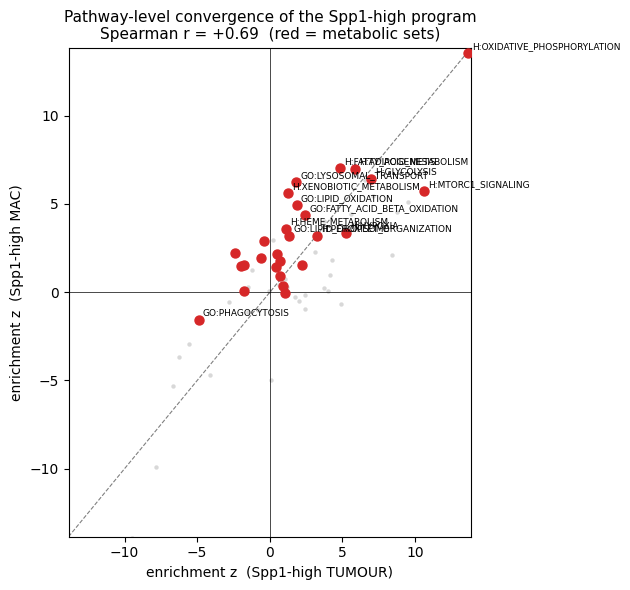

pathway-level convergence: Spearman r(z_tum, z_mac) = +0.688  (p=1.8e-10)

=== metabolic programs by convergence (min z across the two compartments) ===
                                                               pathway_tum  z_tum  z_mac  fdr_rank_tum  fdr_rank_mac
                                               H:OXIDATIVE_PHOSPHORYLATION 13.641 13.543         0.000         0.000
                                                              H:GLYCOLYSIS  6.934  6.422         0.000         0.000
                                                            H:ADIPOGENESIS  5.876  6.992         0.000         0.000
                                                        H:MTORC1_SIGNALING 10.581  5.724         0.000         0.000
                                                   H:FATTY_ACID_METABOLISM  4.794  7.029         0.000         0.000
                                                                 H:HYPOXIA  5.223  3.373         0.000         0.002
                            

In [13]:
# %% -- 5c. Pathway-level convergence: same programs enriched in Spp1-high tumour AND macs? --
comp = enr_tum.merge(enr_mac, on="raw", suffixes=("_tum", "_mac"))
rho_z, p_z = spearmanr(comp["z_tum"], comp["z_mac"])
comp.to_csv(OUT_DIR / "sc_enrichment_convergence_tumour_vs_mac.csv", index=False)

metab = comp[comp["metabolic_tum"]]
fig, ax = plt.subplots(figsize=(6.4, 6))
ax.scatter(comp["z_tum"], comp["z_mac"], s=10, alpha=0.3, color="#7f7f7f", linewidths=0)
ax.scatter(metab["z_tum"], metab["z_mac"], s=42, color="#d62728", zorder=3)
for _, r in metab.iterrows():
    if abs(r["z_tum"]) > 3 or abs(r["z_mac"]) > 3:
        ax.annotate(r["pathway_tum"], (r["z_tum"], r["z_mac"]), fontsize=6.5,
                    xytext=(3, 3), textcoords="offset points")
lim = float(np.nanpercentile(np.abs(np.r_[comp["z_tum"], comp["z_mac"]]), 99)) or 1.0
ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.8, alpha=0.5)
ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("enrichment z  (Spp1-high TUMOUR)"); ax.set_ylabel("enrichment z  (Spp1-high MAC)")
ax.set_title(f"Pathway-level convergence of the Spp1-high program\nSpearman r = {rho_z:+.2f}  (red = metabolic sets)", fontsize=11)
fig.tight_layout(); fig.savefig(FIG_DIR / "sc_enrichment_convergence.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

metab_sorted = metab.assign(min_z=metab[["z_tum", "z_mac"]].min(axis=1)).sort_values("min_z", ascending=False)
print(f"pathway-level convergence: Spearman r(z_tum, z_mac) = {rho_z:+.3f}  (p={p_z:.1e})\n")
print("=== metabolic programs by convergence (min z across the two compartments) ===")
print(metab_sorted[["pathway_tum", "z_tum", "z_mac", "fdr_rank_tum", "fdr_rank_mac"]]
      .round(3).to_string(index=False))
print(f"""
READ
  upper-right (both z>0)  -> convergent: induced with Spp1 in tumour AND macrophage (shared niche).
  off-diagonal            -> compartment-specific labour. Expect oxLDL-response / cholesterol-EFFLUX
      / scavenger / phagocytosis high in MAC not tumour (macs clear lipid; tumour makes it), and
      cholesterol-BIOSYNTHESIS / OxPhos stronger in tumour. Pathway r = {rho_z:+.2f} is the coarse,
      robust echo of the gene-level r in section 6.""")

In [ ]:
# %% -- 5d. CONTROL: does the enrichment survive a tie-corrected Wilcoxon? --
#
# scanpy's rank_genes_groups(method="wilcoxon") uses tie_correct=False BY DEFAULT.
# scRNA-seq is mostly zeros, so every gene carries one huge tie block. Ties shrink the true
# variance of the rank sum, so the uncorrected formula OVERSTATES sd and DEFLATES |score| --
# and it deflates SPARSE genes far more than dense ones:
#       detected in ~8% of cells -> reported |z| ~2.1x too small
#       detected in ~50%         -> ~1.15x too small
#       detected in ~95%         -> essentially unaffected
# Section 5b then ranks genes BY that score, so a set built from ubiquitously-detected genes
# (OxPhos, glycolysis, ribosome-adjacent) can float to the top on detection rate rather than
# biology. That is the competing explanation for H:OXIDATIVE_PHOSPHORYLATION hitting z~13.6 in
# BOTH compartments. This cell tests it and contrasts every number against 5b/5c.
#
# RUNTIME: tie_correct=True computes ties per gene and is much slower than the default.
# Budget several minutes to tens of minutes on the full reference.

import inspect
assert "tie_correct" in inspect.signature(sc.tl.rank_genes_groups).parameters, \
    "installed scanpy predates tie_correct (needs >= 1.5)"

# --- 1. recompute both DEs with the tie-corrected Wilcoxon ------------------------------
de_tum_tc = de_high_vs_low((sc_ct == TUMOUR_LABEL).values, "tumour", tie_correct=True)
de_mac_tc = de_high_vs_low(sc_ct.isin(MAC_LABELS).values, "mac", tie_correct=True)
de_tum_tc.to_csv(OUT_DIR / "sc_de_spp1_tumour_tiecorr.csv", index=False)
de_mac_tc.to_csv(OUT_DIR / "sc_de_spp1_mac_tiecorr.csv", index=False)

enr_tum_tc = enrich_de(de_tum_tc, "tumour_tiecorr")
enr_mac_tc = enrich_de(de_mac_tc, "mac_tiecorr")

# --- 2. gene level: does the correction inflate SPARSE genes most? ----------------------
def gene_shift(de_old, de_new, tag):
    g = de_old.merge(de_new, on="gene", suffixes=("_old", "_new"))
    g["det"] = g[["pct_high_new", "pct_low_new"]].mean(axis=1)
    sel = g[g["score_old"].abs() > 0.5].copy()          # ratio is unstable near score 0
    sel["infl"] = sel["score_new"].abs() / sel["score_old"].abs()
    dec = pd.qcut(sel["det"], 10, labels=False, duplicates="drop")
    tab = (sel.groupby(dec).agg(mean_detection=("det", "mean"), n_genes=("gene", "size"),
                                median_z_inflation=("infl", "median")))
    print(f"\n=== [{tag}] effect of tie correction, by gene detection-rate decile ===")
    print("(inflation = |z_tiecorrected| / |z_uncorrected|;  1.0 = unaffected)")
    print(tab.round(3).to_string())
    return g

g_tum = gene_shift(de_tum, de_tum_tc, "tumour")
g_mac = gene_shift(de_mac, de_mac_tc, "mac")

# --- 3. pathway level: is pathway z just tracking detection rate? -----------------------
def path_shift(enr_old, enr_new, de_new, tag):
    c = enr_old[["raw", "pathway", "n_genes", "z", "fdr_rank", "metabolic"]].merge(
        enr_new[["raw", "z", "fdr_rank"]], on="raw", suffixes=("_old", "_new"))
    det = de_new.set_index("gene")[["pct_high", "pct_low"]].mean(axis=1)
    c["set_detection"] = [float(det.reindex([x for x in set(panel[raw]) if x in det.index]).mean())
                          for raw in c["raw"]]
    c["dz"] = c["z_new"] - c["z_old"]
    c["rank_old"] = c["z_old"].rank(ascending=False)
    c["rank_new"] = c["z_new"].rank(ascending=False)
    c["drank"] = c["rank_new"] - c["rank_old"]
    r_old, p_old = spearmanr(c["set_detection"], c["z_old"])
    r_new, p_new = spearmanr(c["set_detection"], c["z_new"])
    print(f"\n=== [{tag}] is pathway z tracking gene DETECTION RATE? (Spearman) ===")
    print(f"  uncorrected   : r = {r_old:+.3f}  (p={p_old:.1e})")
    print(f"  tie-corrected : r = {r_new:+.3f}  (p={p_new:.1e})")
    print("  -> large positive r = the ranking is partly a sparsity ranking, not biology.")
    return c

c_tum = path_shift(enr_tum, enr_tum_tc, de_tum_tc, "tumour")
c_mac = path_shift(enr_mac, enr_mac_tc, de_mac_tc, "mac")

# --- 4. the headline contrast ----------------------------------------------------------
comp_tc = enr_tum_tc.merge(enr_mac_tc, on="raw", suffixes=("_tum", "_mac"))
rho_tc, p_tc = spearmanr(comp_tc["z_tum"], comp_tc["z_mac"])
comp_tc.to_csv(OUT_DIR / "sc_enrichment_convergence_tumour_vs_mac_tiecorr.csv", index=False)

show = (c_tum[["raw", "pathway", "n_genes", "set_detection", "z_old", "z_new", "dz", "drank",
               "fdr_rank_old", "fdr_rank_new", "metabolic"]]
        .merge(c_mac[["raw", "z_old", "z_new"]], on="raw", suffixes=("_tum", "_mac")))
met_cmp = show[show["metabolic"]].sort_values("z_new_tum", ascending=False)

print("\n" + "=" * 104)
print("=== METABOLIC SETS: uncorrected (old) vs tie-corrected (new), both compartments ===")
print(met_cmp[["pathway", "n_genes", "set_detection", "z_old_tum", "z_new_tum",
               "z_old_mac", "z_new_mac", "drank"]].round(3).to_string(index=False))

print("\n=== biggest RANK movers, tumour panel (all sets) ===")
print(c_tum.reindex(c_tum["drank"].abs().sort_values(ascending=False).index)
      .head(15)[["pathway", "n_genes", "set_detection", "z_old", "z_new", "rank_old", "rank_new"]]
      .round(3).to_string(index=False))

# --- 5. figure: pathway z before vs after, coloured by detection rate -------------------
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2))
for ax, c, ttl in [(axes[0], c_tum, "TUMOUR"), (axes[1], c_mac, "MAC")]:
    pcm = ax.scatter(c["z_old"], c["z_new"], c=c["set_detection"], cmap="viridis",
                     s=36, edgecolors="k", linewidths=0.3)
    lim = float(np.nanmax(np.abs(np.r_[c["z_old"], c["z_new"]]))) * 1.05
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.8, alpha=0.6)
    ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel("enrichment z  (uncorrected)")
    ax.set_ylabel("enrichment z  (tie-corrected)")
    ax.set_title(f"{ttl}: pathway z before vs after tie correction", fontsize=10)
    fig.colorbar(pcm, ax=ax, label="mean detection rate of set genes")
fig.tight_layout(); fig.savefig(FIG_DIR / "sc_tiecorrection_control.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

# --- 6. verdict, computed from the numbers (not hardcoded) -----------------------------
det_r_old = spearmanr(c_tum["set_detection"], c_tum["z_old"])[0]
det_r_new = spearmanr(c_tum["set_detection"], c_tum["z_new"])[0]
ox = "HALLMARK_OXIDATIVE_PHOSPHORYLATION"
ox_t_old = float(comp.loc[comp["raw"] == ox, "z_tum"].iloc[0])
ox_t_new = float(comp_tc.loc[comp_tc["raw"] == ox, "z_tum"].iloc[0])
ox_m_old = float(comp.loc[comp["raw"] == ox, "z_mac"].iloc[0])
ox_m_new = float(comp_tc.loc[comp_tc["raw"] == ox, "z_mac"].iloc[0])
n_flip = int(((met_cmp["fdr_rank_old"] < 0.05) != (met_cmp["fdr_rank_new"] < 0.05)).sum())

print(f"""
{'=' * 104}
CONTRAST SUMMARY  (5b/5c uncorrected  ->  5d tie-corrected)

  convergence r(z_tum, z_mac)      {rho_z:+.3f}  ->  {rho_tc:+.3f}
  pathway z vs detection rate (tum) {det_r_old:+.3f}  ->  {det_r_new:+.3f}
  H:OXPHOS z, tumour               {ox_t_old:+.2f}  ->  {ox_t_new:+.2f}
  H:OXPHOS z, mac                  {ox_m_old:+.2f}  ->  {ox_m_new:+.2f}
  metabolic sets flipping FDR<0.05 (tumour): {n_flip} of {len(met_cmp)}

HOW TO READ
  * If 'pathway z vs detection rate' stays high after correction, the pathway ranking is
    still confounded by sparsity and the metabolic ordering should not be read as biology.
    Report AUC alongside z, and compare sets of similar size and detection rate.
  * If OxPhos drops sharply while the lipid/cholesterol split (5c off-diagonal) holds, the
    compartment-specific lipid story is the robust result and OxPhos was largely detection.
  * If both barely move, the tie confound was not driving 5b/5c and the original read stands.
""")


## 6. Q3 — DO THEY CONVERGE? (the honest test)

Correlate the Spp1-high-vs-low **fold-change vectors** of tumour and macrophages over their
shared genes. Positive correlation = the *same genes* move the *same way* when Spp1 is high in
either compartment: a shared metabolic program, not just shared Spp1.

Deliberately **not** using the mac-specific 01c signature — that would be rigged to say "no".

In [9]:
m = de_tum.merge(de_mac, on="gene", suffixes=("_tum", "_mac"))
# focus on genes significant in at least one compartment
sig = m[(m["pval_adj_tum"] < 0.05) | (m["pval_adj_mac"] < 0.05)].copy()
rho, p = spearmanr(sig["log2FC_tum"], sig["log2FC_mac"])
r_pear = np.corrcoef(sig["log2FC_tum"], sig["log2FC_mac"])[0, 1]

# shared UP genes (the concrete convergent program)
up_tum = set(de_tum[(de_tum["log2FC"] > 0.5) & (de_tum["pval_adj"] < 0.05)]["gene"])
up_mac = set(de_mac[(de_mac["log2FC"] > 0.5) & (de_mac["pval_adj"] < 0.05)]["gene"])
shared = up_tum & up_mac
jacc = len(shared) / len(up_tum | up_mac) if (up_tum | up_mac) else np.nan

print(f"""=== convergence of the Spp1-high program: tumour vs macrophage ===
  genes compared (sig in >=1) : {len(sig):,}
  Spearman r (log2FC vectors) : {rho:+.3f}   (p={p:.1e})
  Pearson  r                  : {r_pear:+.3f}
  UP genes: tumour={len(up_tum)}  mac={len(up_mac)}  shared={len(shared)}  Jaccard={jacc:.3f}

  r strongly + (say >0.4) -> convergence: Spp1-high tumour and Spp1-high macs turn on the same
      program. The shared genes below ARE the shared metabolic state - the metabolism story.
  r ~ 0 -> no shared program; Spp1-high means different things in each compartment. Then the
      macrophage metabolic state stands on its own (01c §4) and is not tumour-mirrored.
""")
print("shared UP genes (Spp1-high in BOTH compartments):")
print(sorted(shared))

# annotate which shared genes are metabolic
metab_genes = set()
for gs in METAB_PANEL.values():
    metab_genes |= set(gene_sets.get(gs, []))
shared_metab = sorted(shared & metab_genes)
print(f"\nof those, in the metabolic panel ({len(shared_metab)}): {shared_metab}")

=== convergence of the Spp1-high program: tumour vs macrophage ===
  genes compared (sig in >=1) : 8,796
  Spearman r (log2FC vectors) : +0.454   (p=0.0e+00)
  Pearson  r                  : +0.423
  UP genes: tumour=4275  mac=1625  shared=818  Jaccard=0.161

  r strongly + (say >0.4) -> convergence: Spp1-high tumour and Spp1-high macs turn on the same
      program. The shared genes below ARE the shared metabolic state - the metabolism story.
  r ~ 0 -> no shared program; Spp1-high means different things in each compartment. Then the
      macrophage metabolic state stands on its own (01c §4) and is not tumour-mirrored.

shared UP genes (Spp1-high in BOTH compartments):
['0610009B22Rik', '0610012G03Rik', '1110004E09Rik', '1700017B05Rik', '1700037H04Rik', '1810058I24Rik', '2010111I01Rik', '2010320M18Rik', '2700094K13Rik', '2810417H13Rik', '3110062M04Rik', '4931406C07Rik', 'Abcc1', 'Abcd3', 'Abhd14a', 'Abhd4', 'Abi2', 'Acbd6', 'Acot13', 'Acp1', 'Actn1', 'Adamtsl5', 'Adgrl2', 'Adh5', 'Adi

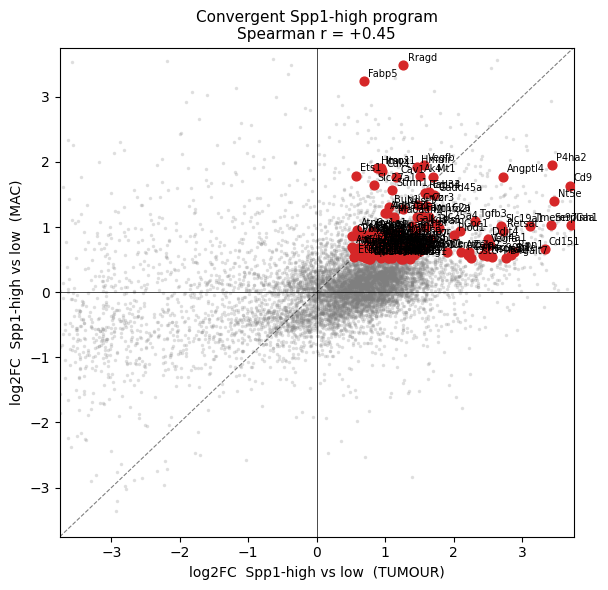

In [10]:
# Scatter of the two fold-change vectors; shared metabolic genes labelled.
fig, ax = plt.subplots(figsize=(6.2, 6))
ax.scatter(sig["log2FC_tum"], sig["log2FC_mac"], s=6, alpha=0.25, color="#7f7f7f", linewidths=0)
lab = sig[sig["gene"].isin(shared_metab)]
ax.scatter(lab["log2FC_tum"], lab["log2FC_mac"], s=40, color="#d62728", zorder=3)
for _, r in lab.iterrows():
    ax.annotate(r["gene"], (r["log2FC_tum"], r["log2FC_mac"]), fontsize=7,
                xytext=(3, 3), textcoords="offset points")
lim = np.nanpercentile(np.abs(np.r_[sig["log2FC_tum"], sig["log2FC_mac"]]), 99)
ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.8, alpha=0.5)
ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("log2FC  Spp1-high vs low  (TUMOUR)"); ax.set_ylabel("log2FC  Spp1-high vs low  (MAC)")
ax.set_title(f"Convergent Spp1-high program\nSpearman r = {rho:+.2f}", fontsize=11)
fig.tight_layout(); fig.savefig(FIG_DIR / "sc_convergence_scatter.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 7. Summary

In [11]:
print(f"""
==================== SUMMARY — report these back ====================
Q1  Cd44 source     : Cancer_cell {tum_cd44:.1f}% vs macrophages {mac_cd44:.1f}% of tissue Cd44 pool
                      (with 01c: tumour makes 53% of Spp1 too -> autocrine loop vs outward signalling)
Q2  Spp1-high tumour: {len(up_tum)} genes UP; metabolic markers listed in §5
Q3  CONVERGENCE     : Spearman r = {rho:+.3f} between tumour and mac Spp1-high fold-changes
                      {len(shared)} shared UP genes, {len(shared_metab)} of them metabolic

INTERPRETATION
 - r high  -> tumour and TAM converge on ONE Spp1-high metabolic program. Strongest possible
              framing for the metabolism angle: a shared niche state, not two coincidences.
 - r low   -> they do NOT share a program; the TAM metabolic state (01c §4) is its own thing.
              Still fundable, just not a tumour-mirrored convergence story.
 - watch Q1: if tumour carries most Cd44 too, the "SPP1-CD44 interaction-high" signal is largely
   tumour autocrine - which sharpens (not weakens) the reframe from notebook 01c §3b.

NOTE: single-cell is dissociated, so a shared program here is transcriptional convergence, not
proof of spatial co-location. Notebooks 02/03 test whether it plays out in tissue space.
=====================================================================
""")


==================== SUMMARY — report these back ====================
Q1  Cd44 source     : Cancer_cell 13.5% vs macrophages 10.3% of tissue Cd44 pool
                      (with 01c: tumour makes 53% of Spp1 too -> autocrine loop vs outward signalling)
Q2  Spp1-high tumour: 4275 genes UP; metabolic markers listed in §5
Q3  CONVERGENCE     : Spearman r = +0.454 between tumour and mac Spp1-high fold-changes
                      818 shared UP genes, 141 of them metabolic

INTERPRETATION
 - r high  -> tumour and TAM converge on ONE Spp1-high metabolic program. Strongest possible
              framing for the metabolism angle: a shared niche state, not two coincidences.
 - r low   -> they do NOT share a program; the TAM metabolic state (01c §4) is its own thing.
              Still fundable, just not a tumour-mirrored convergence story.
 - watch Q1: if tumour carries most Cd44 too, the "SPP1-CD44 interaction-high" signal is largely
   tumour autocrine - which sharpens (not weakens) the r